In [10]:
import torch
import open3d as o3d
import numpy as np
import os
import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split


root_dir = r"C:\Users\SHUS\PY\ModelNet10" 


all_files = []
all_labels = []
classes = sorted(os.listdir(root_dir))
class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    class_dir = os.path.join(root_dir, cls)
    for file_path in glob.glob(os.path.join(class_dir, "**", "*.off"), recursive=True):
        all_files.append(file_path)
        all_labels.append(class_to_idx[cls])

print(f" {len(all_files)} models had been found，Reading and sampling in progress (this step will take a few minutes, please patiently wait for the progress bar to complete)...")


X_data = []
y_data = []

for path, label in tqdm(zip(all_files, all_labels), total=len(all_files)):
    mesh = o3d.io.read_triangle_mesh(path)
    pcd = mesh.sample_points_uniformly(number_of_points=1024)
    X_data.append(np.asarray(pcd.points))
    y_data.append(label)


X_tensor = torch.tensor(np.array(X_data), dtype=torch.float32) # [N, 1024, 3]
y_tensor = torch.tensor(np.array(y_data), dtype=torch.long)    # [N]


X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)


torch.save((X_train, y_train), "modelnet10_train.pt")
torch.save((X_test, y_test), "modelnet10_test.pt")
print("Data preprocessing is complete！Saved as modelnet10_train.pt and modelnet10_test.pt")

 4899 models had been found，Reading and sampling in progress (this step will take a few minutes, please patiently wait for the progress bar to complete)...


100%|██████████| 4899/4899 [02:33<00:00, 31.85it/s]


Data preprocessing is complete！Saved as modelnet10_train.pt and modelnet10_test.pt


trainset: 3919, testset: 980
Start training (equipped with early stopping mechanism)...
Epoch [1/100000], Loss: 76.4332, LR: 0.01000
Epoch [2/100000], Loss: 6.6595, LR: 0.01000
Epoch [3/100000], Loss: 2.8002, LR: 0.01000
Epoch [4/100000], Loss: 2.2169, LR: 0.01000
Epoch [5/100000], Loss: 2.3481, LR: 0.01000
 Loss No significant improvement, number of times endured: 1/20
Epoch [6/100000], Loss: 2.4998, LR: 0.01000
 Loss No significant improvement, number of times endured: 2/20
Epoch [7/100000], Loss: 1.9841, LR: 0.01000
Epoch [8/100000], Loss: 1.7710, LR: 0.01000
Epoch [9/100000], Loss: 1.6329, LR: 0.01000
Epoch [10/100000], Loss: 1.6725, LR: 0.01000
 Loss No significant improvement, number of times endured: 1/20
Epoch [11/100000], Loss: 1.6012, LR: 0.01000
Epoch [12/100000], Loss: 1.6516, LR: 0.01000
 Loss No significant improvement, number of times endured: 1/20
Epoch [13/100000], Loss: 1.5275, LR: 0.01000
Epoch [14/100000], Loss: 1.4507, LR: 0.01000
Epoch [15/100000], Loss: 1.2554, L

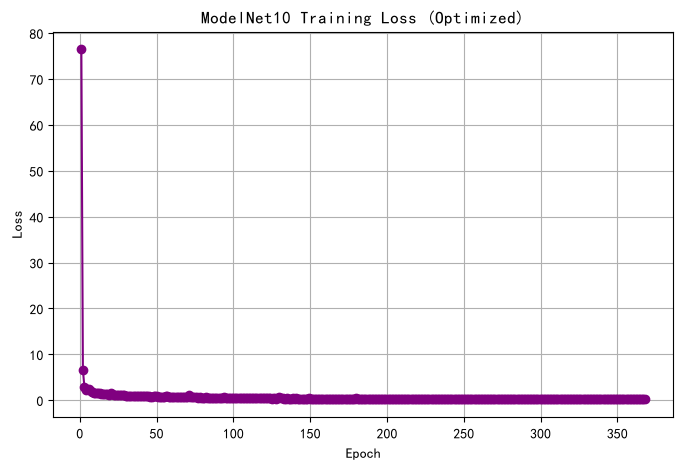

In [12]:
import torch
import open3d as o3d
import numpy as np
import os
import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class CachedDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        points = self.X[idx].clone()
        label = self.y[idx]
        
        if self.augment:
        
            theta = np.random.uniform(0, 2 * np.pi)
            rot = np.array([[np.cos(theta), -np.sin(theta), 0],
                            [np.sin(theta),  np.cos(theta), 0],
                            [0,              0,             1]])
            points = points @ torch.tensor(rot, dtype=torch.float32).T
            points = points * np.random.uniform(0.8, 1.2)
            points = points + torch.tensor(np.random.uniform(-0.1, 0.1, (1, 3)), dtype=torch.float32)
            
        return points, label


X_train, y_train = torch.load("modelnet10_train.pt")
X_test, y_test = torch.load("modelnet10_test.pt")

train_dataset = CachedDataset(X_train, y_train, augment=True)
test_dataset = CachedDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

print(f"trainset: {len(train_dataset)}, testset: {len(test_dataset)}")


class MiniPointNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(3, 128), nn.ReLU(),   
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512)             
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        features = self.mlp(x)
        global_feature, _ = torch.max(features, dim=1)
        return self.classifier(global_feature)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniPointNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.9)

epochs = 100000 
loss_history = []

patience = 20          
min_delta = 1e-4       
best_loss = float('inf') 
patience_counter = 0   

print("Start training (equipped with early stopping mechanism)...")
for epoch in range(epochs):
    model.train()
    epoch_loss_tensor = torch.tensor(0.0, device=device)
    
    for batch_points, batch_labels in train_loader:
        batch_points, batch_labels = batch_points.to(device), batch_labels.to(device)
        
        outputs = model(batch_points)
        loss = criterion(outputs, batch_labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss_tensor += loss.detach()

    scheduler.step()
    avg_loss = epoch_loss_tensor.item() / len(train_loader)
    loss_history.append(avg_loss)
    
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, LR: {current_lr:.5f}")
    if best_loss - avg_loss > min_delta:
        best_loss = avg_loss
        patience_counter = 0 
        torch.save(model.state_dict(), "best_model.pt") 
    else:
        patience_counter += 1
        print(f" Loss No significant improvement, number of times endured: {patience_counter}/{patience}")
    if patience_counter >= patience:
        print(f"\n early stopping is triggling！finish training at round {epoch+1}")
        break

print(f"training finished，the best Loss recorded: {best_loss:.4f}")



model.eval()
correct_tensor = torch.tensor(0, device=device)
total_tensor = torch.tensor(0, device=device)

with torch.no_grad():
    for batch_points, batch_labels in test_loader:
        batch_points, batch_labels = batch_points.to(device), batch_labels.to(device)
        outputs = model(batch_points)
        _, predicted = torch.max(outputs.data, 1)
        total_tensor += batch_labels.size(0)
        correct_tensor += (predicted == batch_labels).sum()

accuracy = 100 * correct_tensor.item() / total_tensor.item()
print(f"\naccuracy on real dataset: {accuracy:.2f}%")

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', color='purple')
plt.title("ModelNet10 Training Loss (Optimized)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()